# P0 · Python Fundamentals for Transformers

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## Chapter index

**Section 1 · Inspect the program**

- P0.1 · Read, run, inspect — P0-python-runtime.ipynb
- P0.2 · Text, positions, and slices — P0-python-text.ipynb
- P0.3 · Containers and shared references — P0-python-containers.ipynb

**Section 2 · Prepare text and data**

- P0.4 · Build a vocabulary — P0-python-vocabulary.ipynb
- P0.5 · Follow iteration and unpacking — P0-python-iteration.ipynb
- P0.6 · Functions with clear contracts — P0-python-functions.ipynb
- P0.7 · Imports, files, and configuration — P0-python-files.ipynb

**Section 3 · Read model code**

- P0.8 · Classes and instances — P0-python-classes.ipynb
- P0.9 · Read real model Python — P0-python-model-python.ipynb
- P0.10 · Text-to-batch capstone — P0-python-pipeline.ipynb

# Section 1 · Inspect the program

- P0.1 · Read, run, inspect
- P0.2 · Text, positions, and slices
- P0.3 · Containers and shared references

## P0.1 · Read, run, inspect

A notebook keeps values between runs. Inspect the current values and rerun dependencies when they change.

**Prerequisites:** Basic variables, loops and functions.

**Predict:** After reassigning text, does an already calculated length update?

**Mental model:** A model notebook is a program with memory. A cell reads values left by earlier executions, even when the visible order looks different.

### P0.1.1 · Understand the need

A model notebook is a program with memory. A cell reads values left by earlier executions, even when the visible order looks different.

Watch a text variable and a separate length variable. Assigning the length calculates an integer at that moment; it does not attach a live formula to the text.

Now change the text without running the length calculation again. Predict whether the stored length follows the new text automatically.

Inspecting both values makes the mismatch visible. Reading code means tracking execution order and current state, as well as understanding individual lines.

Begin experiments with a restart and run all. That makes hidden dependencies visible before they affect a model result.

### P0.1.2 · Follow the values

The source contains the letters t and o, a space, b and e, and a newline. The representation exposes that otherwise hidden newline.

Counting this source gives 6 positions. The integer is stored under the name length.

Reassign text to the shorter phrase without its newline. The source now contains 5 positions, but no length calculation has run.

The stored integer is still 6. Changing one name does not automatically recompute another name that was calculated from it.

Run the length expression again. Its result now matches the current text. Choose the longer phrase in the lab and repeat the same reasoning.

In [3]:
FRAMES.clear()
change = 0
text = "to be\n"
show("Source text", repr(text))
length = len(text)
show("Count including the newline", length)
text = "to be or not" if change else "to be"
show("Reassigned text", repr(text))
show("Old length is still stored", length)
length = len(text)
show("Recomputed length", length)

Source text: "'to be\\n'"
Count including the newline: 6
Reassigned text: "'to be'"
Old length is still stored: 6
Recomputed length: 5


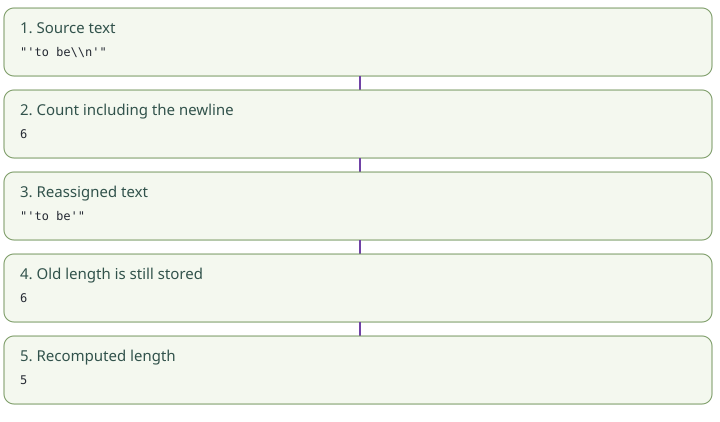

In [4]:
draw_trace()

### P0.1.3 · Read and run the code

Read the assignment to text first. Quotes create a string, and the backslash escape represents a newline inside it.

The function len returns the number of positions in the string. The show helper prints a named intermediate value for this notebook.

The conditional expression chooses the experiment input. Its purpose is to change one cause while leaving the remaining lines identical.

Two calls inspect the new text and the previously stored integer. Print is an observation; it does not repair a stale calculation.

Recompute length explicitly. If execution fails, read the exception type and the last relevant line of the traceback before changing the program.

### Change one thing

**Use a longer replacement string**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
text = "to be\n"
show("Source text", repr(text))
length = len(text)
show("Count including the newline", length)
text = "to be or not" if change else "to be"
show("Reassigned text", repr(text))
show("Old length is still stored", length)
length = len(text)
show("Recomputed length", length)

Source text: "'to be\\n'"
Count including the newline: 6
Reassigned text: "'to be or not'"
Old length is still stored: 6
Recomputed length: 12


### A useful distinction

A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.

In [6]:
sample = "a\nb"
assert len(sample) == 3 and repr(sample) == "'a\\nb'"
try:
    len(3)
except TypeError as error:
    print(type(error).__name__, str(error))
print("A traceback identifies the operation and the values it could not accept.")

TypeError object of type 'int' has no len()
A traceback identifies the operation and the values it could not accept.


### ✋ Your turn

Reassign text to "hello", then calculate its current length in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 5, 'A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
text = "hello"
answer = len(text)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 5, 'A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.'
    print("✓ right:", answer)

✓ right: 5


### P0.1.4 · Find it in the model

Training code calculates batches, predictions and loss in an order. A previous loss value can remain in notebook memory after you change the batch.

Imports create names too. The alias torch refers to a module, while model refers to a particular object you constructed.

Inspect type, shape and a small sample at a boundary. These observations tell you what the next operation will actually receive.

A reproducible notebook runs from its first setup cell to its last result after restarting the kernel. Printed output from an older execution is not evidence of a new one.

This habit prepares every later experiment. Next, inspect the positions and boundaries inside the text itself.

```python
batch = get_batch()
logits, loss = model(*batch)
print(loss.item())
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** After reassigning text, does an already calculated length update?

<details><summary>Check your explanation</summary>

No; run the calculation again. A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.

</details>

## P0.2 · Text, positions, and slices

A slice includes its start and excludes its stop. Text positions and encoded byte positions are different units.

**Prerequisites:** Read, run, inspect

**Predict:** What does "abcdef"[1:4] return?

**Mental model:** A transformer receives a limited context window. Before creating tensors, you need to say exactly which text positions belong to that window.

### P0.2.1 · Understand the need

A transformer receives a limited context window. Before creating tensors, you need to say exactly which text positions belong to that window.

Python starts counting at zero. A slice uses a starting boundary and an ending boundary, so three positions lie between boundaries zero and three.

Move both boundaries one place to obtain the next window. Move the target window one place ahead to describe the next-character prediction task.

Whitespace is data. A space or newline may be visually quiet while still occupying a position and needing its own character ID.

Keep the unit of counting explicit. A Python string, a U T F eight byte sequence and a tokenizer's tokens can have different lengths.

### P0.2.2 · Follow the values

Lay out the six positions of the example, with a visible space tile and a visible newline tile.

The first three-position slice selects t, o and the space. The ending boundary does not select the character b at position three.

Shift the same window one place forward. The targets become o, the space and b: one next character for every input position.

A negative index counts back from the end. Index minus one selects the newline, whose representation makes the escape visible.

The accented letter has one Python string position here and two U T F eight bytes, 195 and 169. Decoding those bytes reconstructs the original text.

In [9]:
FRAMES.clear()
change = 0
text = "to be\n"
show("Characters, including whitespace", list(text))
start = 1 if change else 0
show("Window text[start:start+3]", list(text[start:start+3]))
show("Shifted next characters", list(text[start+1:start+4]))
show("Last character, shown explicitly", repr(text[-1]))
show("Text versus UTF-8 bytes", {"text": "é", "text positions": len("é"), "bytes": list("é".encode("utf-8"))})

Characters, including whitespace: ["t", "o", " ", "b", "e", "\n"]
Window text[start:start+3]: ["t", "o", " "]
Shifted next characters: ["o", " ", "b"]
Last character, shown explicitly: "'\\n'"
Text versus UTF-8 bytes: {"text": "é", "text positions": 1, "bytes": [195, 169]}


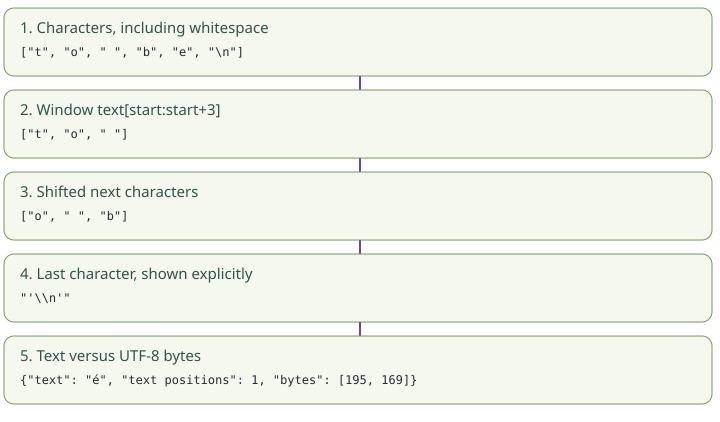

In [10]:
draw_trace()

### P0.2.3 · Read and run the code

Use list of text to expose its positions. The notebook helper renders whitespace explicitly so a blank tile cannot be mistaken for missing data.

The start variable is the experiment control. Both window boundaries move together, preserving the requested window length when enough text remains.

The target expression adds one to both boundaries. Check equal input and target lengths before using a pair for training.

Indexing returns one element; slicing returns a sequence. An oversized slice stops at the available boundary, while an out-of-range single index raises an error.

Encode with U T F eight to inspect bytes and decode with the same encoding to recover text. Later tokenization adds a separate mapping from text pieces to token IDs.

### Change one thing

**Move the window start from 0 to 1**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [11]:
FRAMES.clear()
change = 1
text = "to be\n"
show("Characters, including whitespace", list(text))
start = 1 if change else 0
show("Window text[start:start+3]", list(text[start:start+3]))
show("Shifted next characters", list(text[start+1:start+4]))
show("Last character, shown explicitly", repr(text[-1]))
show("Text versus UTF-8 bytes", {"text": "é", "text positions": len("é"), "bytes": list("é".encode("utf-8"))})

Characters, including whitespace: ["t", "o", " ", "b", "e", "\n"]
Window text[start:start+3]: ["o", " ", "b"]
Shifted next characters: [" ", "b", "e"]
Last character, shown explicitly: "'\\n'"
Text versus UTF-8 bytes: {"text": "é", "text positions": 1, "bytes": [195, 169]}


### A useful distinction

String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.

In [12]:
assert "é".encode("utf-8").decode("utf-8") == "é"
assert len("e\u0301") == 2  # one displayed accented letter, two code points
assert "abc"[10:20] == ""
try:
    "abc"[10]
except IndexError:
    print("An index failed; a slice would have been empty.")

An index failed; a slice would have been empty.


### ✋ Your turn

For text="abcdef", return the two strings for a length-3 input window starting at 1 and its shifted targets.

In [13]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ("bcd", "cde"), 'String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [14]:
#@title Show a solution { display-mode: "form" }
text = "abcdef"
answer = (text[1:4], text[2:5])

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ("bcd", "cde"), 'String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.'
    print("✓ right:", answer)

✓ right: ('bcd', 'cde')


### P0.2.4 · Find it in the model

The current character model constructs input and target slices from one encoded stream. Their one-position offset is the supervision signal.

During generation, a negative slice keeps only the most recent context that fits the model. Cropping a context changes which positions are available.

The character model and Phyll use different tokenizers. A U T F eight byte is not automatically one Phyll token, and a token is not necessarily one displayed character.

Tokenization details belong in the later tokenizer lesson. Here the transferable skill is tracking the representation and the boundaries you are slicing.

Next, examine the containers that hold those positions, and the difference between changing a container and copying it.

```python
x = data[start:start + context]
y = data[start + 1:start + context + 1]
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What does "abcdef"[1:4] return?

<details><summary>Check your explanation</summary>

bcd. String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.

</details>

## P0.3 · Containers and shared references

Assignment shares an object. A shallow copy creates a new outer container while nested objects may remain shared.

**Prerequisites:** Text, positions, and slices

**Predict:** After b=a, does b[0]=9 also affect a?

**Mental model:** Two variable names can refer to the same list. A name is a way to reach an object; it is not a box that automatically receives a fresh copy.

<a id="python-names"></a>

<a data-compat-cell="p0-names-lists-and-dicts"></a>

### P0.3.1 · Understand the need

Two variable names can refer to the same list. A name is a way to reach an object; it is not a box that automatically receives a fresh copy.

Imagine drawing arrows from both names to a single list. Editing through either arrow reaches the same stored elements.

Copying the outer list changes this picture, but nested lists introduce another layer of arrows. Their contents may still be shared.

This is useful when sharing is intentional and confusing when it is accidental. Predict the object relationships before predicting the printed values.

Later, tensor views and tied model weights will reuse this distinction between a new name, a new container and independent storage.

### P0.3.2 · Follow the values

The starting list contains 2, 0 and 1. In the first experiment, both names refer to that same object.

Assign 9 through b at position zero. Reading a now sees the changed value too. Switch to the copy experiment to keep a unchanged.

Make a shallow copy of a nested list. The outer containers are different objects, as the identity comparison confirms.

Append 3 to the first inner list through the copy. Both outer containers still refer to that inner list, so the original also displays the appended value.

A comprehension creates a fresh inner list on each iteration. Editing the first leaves the second alone. The diagram now has two independent inner objects.

In [15]:
FRAMES.clear()
change = 0
a = [2, 0, 1]
b = a.copy() if change else a
show("Before the change", {"a": a.copy(), "b": b.copy(), "same object": a is b})
b[0] = 9
show("After b[0] = 9", {"a": a.copy(), "b": b.copy()})
nested = [[1], [2]]
outer_copy = nested.copy()
show("New outer list", nested is outer_copy)
outer_copy[0].append(3)
show("Shared inner list", nested)
independent = [[0] for _ in range(2)]
independent[0].append(7)
show("Independent inner lists", independent)

Before the change: {"a": [2, 0, 1], "b": [2, 0, 1], "same object": true}
After b[0] = 9: {"a": [9, 0, 1], "b": [9, 0, 1]}
New outer list: false
Shared inner list: [[1, 3], [2]]
Independent inner lists: [[0, 7], [0]]


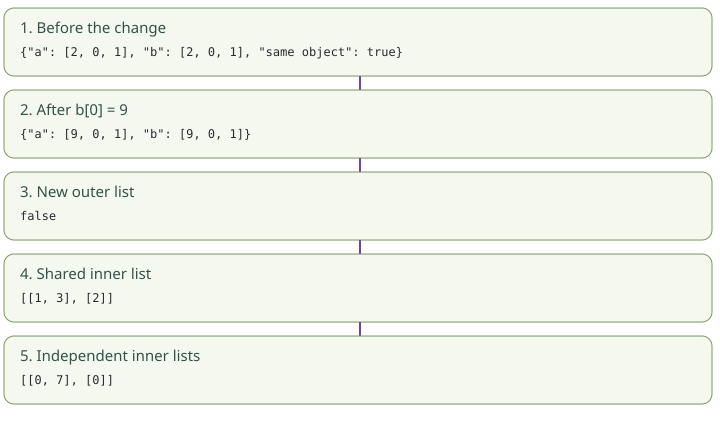

In [16]:
draw_trace()

### P0.3.3 · Read and run the code

Read the assignment that chooses either the same object or a shallow copy. The identity operator asks whether two names reach the same object.

Item assignment mutates an existing list. Reassigning the name b would instead redirect that name without editing the old list.

Copying a nested container only copies its outer layer. Inspect the inner references before assuming that all descendants are independent.

Append adds one object; extend adds the elements from another iterable. A tuple prevents replacing its own entries, although an entry can itself refer to a mutable list.

For independent inner lists, construct them separately in a comprehension. Avoid repeating a single mutable inner list when you intend separate state.

### Change one thing

**Copy the list before changing b**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [17]:
FRAMES.clear()
change = 1
a = [2, 0, 1]
b = a.copy() if change else a
show("Before the change", {"a": a.copy(), "b": b.copy(), "same object": a is b})
b[0] = 9
show("After b[0] = 9", {"a": a.copy(), "b": b.copy()})
nested = [[1], [2]]
outer_copy = nested.copy()
show("New outer list", nested is outer_copy)
outer_copy[0].append(3)
show("Shared inner list", nested)
independent = [[0] for _ in range(2)]
independent[0].append(7)
show("Independent inner lists", independent)

Before the change: {"a": [2, 0, 1], "b": [2, 0, 1], "same object": false}
After b[0] = 9: {"a": [2, 0, 1], "b": [9, 0, 1]}
New outer list: false
Shared inner list: [[1, 3], [2]]
Independent inner lists: [[0, 7], [0]]


### A useful distinction

Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.

### ✋ Your turn

Create two independent empty lists in answer, then append 7 only to the first.

In [18]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[7], []] and answer[0] is not answer[1], 'Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [19]:
#@title Show a solution { display-mode: "form" }
answer = [[] for _ in range(2)]
answer[0].append(7)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[7], []] and answer[0] is not answer[1], 'Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.'
    print("✓ right:", answer)

✓ right: [[7], []]


### P0.3.4 · Find it in the model

Model weights can be shared deliberately. The token embedding and the readout may refer to the same learned tensor rather than two equal copies.

A tensor view can also share storage. Changing a view may affect the original, even when the two tensors have different shapes.

Python assignment, a tensor clone and detaching a tensor answer different questions. PyTorch will teach storage independence separately from gradient recording.

Training checkpoints need a preserved state, not an accidental reference to numbers that training continues to modify. That is why copying and serialization matter.

Next, use a different container: a dictionary that maps a character to its ID.

```python
best_state = copy.deepcopy(model.state_dict())
# Preserve a snapshot while training continues.
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** After b=a, does b[0]=9 also affect a?

<details><summary>Check your explanation</summary>

Yes; both names reach the same list. Equal values do not prove separate storage. A shallow copy does not recursively copy nested objects.

</details>

# Section 2 · Prepare text and data

- P0.4 · Build a vocabulary
- P0.5 · Follow iteration and unpacking
- P0.6 · Functions with clear contracts
- P0.7 · Imports, files, and configuration

## P0.4 · Build a vocabulary

A vocabulary gives each known character one ID. A reverse mapping reconstructs the text from those IDs.

**Prerequisites:** Containers and shared references

**Predict:** What changes when a known character repeats?

**Mental model:** The model performs calculations on numbers, but text begins as characters. A vocabulary provides a reversible naming system between those representations.

### P0.4.1 · Understand the need

The model performs calculations on numbers, but text begins as characters. A vocabulary provides a reversible naming system between those representations.

An ID names a character; a larger ID does not mean a more important character. The learned embedding supplies the vector used for calculation later.

A set removes repeated characters, and sorting makes the order of this illustrative vocabulary explicit. Enumerating assigns an index in that order.

Repeating a letter in the text should repeat its ID, not create a new vocabulary entry. Predict what changes when the final letter appears twice.

Keep the vocabulary with the model. Changing the mapping while keeping learned weights would give old vectors new meanings.

### P0.4.2 · Follow the values

Start with t, o, a space, b and e. The text has five positions, each of which will receive an ID.

The sorted vocabulary contains a space, b, e, o and t. Repeated occurrences would still contribute only one entry to this set.

Enumerating those entries creates IDs zero through four. The dictionary pairs each character with its lookup result.

Look up the original positions in order. The encoded text is 4, 3, 0, 1, 2. In the second experiment the extra e adds another 2.

Index the vocabulary by each ID and join the characters. The round trip must return the exact source, including whitespace.

In [20]:
FRAMES.clear()
change = 0
text = "to be" if not change else "to bee"
show("Text positions", list(text))
chars = sorted(set(text))
show("Sorted unique characters", chars)
stoi = {ch: i for i, ch in enumerate(chars)}
show("Character to ID", stoi)
ids = [stoi[ch] for ch in text]
show("Encoded positions", ids)
decoded = "".join(chars[i] for i in ids)
show("Decoded text", decoded)
assert decoded == text

Text positions: ["t", "o", " ", "b", "e"]
Sorted unique characters: [" ", "b", "e", "o", "t"]
Character to ID: {" ": 0, "b": 1, "e": 2, "o": 3, "t": 4}
Encoded positions: [4, 3, 0, 1, 2]
Decoded text: "to be"


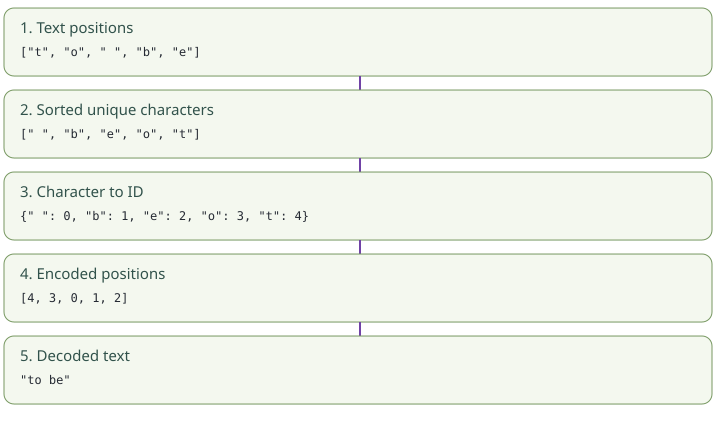

In [21]:
draw_trace()

### P0.4.3 · Read and run the code

Set collects unique characters; sorted returns them in a deterministic order for this example. Do not rely on the iteration order of a set for a saved vocabulary.

Enumerate produces pairs containing a position and a character. The dictionary comprehension uses those pairs to build the forward mapping.

The list comprehension performs one dictionary lookup per source character. A missing character raises a KeyError in this closed-vocabulary example.

The reverse direction uses the vocabulary list itself: its position is the ID. Join combines the recovered characters without inserting extra spaces.

Assert the round trip, and separately check an unknown character. Choosing an unknown-token policy belongs to the tokenizer design, not an accidental exception handler.

### Change one thing

**Repeat the final e**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [22]:
FRAMES.clear()
change = 1
text = "to be" if not change else "to bee"
show("Text positions", list(text))
chars = sorted(set(text))
show("Sorted unique characters", chars)
stoi = {ch: i for i, ch in enumerate(chars)}
show("Character to ID", stoi)
ids = [stoi[ch] for ch in text]
show("Encoded positions", ids)
decoded = "".join(chars[i] for i in ids)
show("Decoded text", decoded)
assert decoded == text

Text positions: ["t", "o", " ", "b", "e", "e"]
Sorted unique characters: [" ", "b", "e", "o", "t"]
Character to ID: {" ": 0, "b": 1, "e": 2, "o": 3, "t": 4}
Encoded positions: [4, 3, 0, 1, 2, 2]
Decoded text: "to bee"


### A useful distinction

The numerical distance between two token IDs does not describe similarity between their meanings.

### ✋ Your turn

Build a sorted vocabulary for "aba ", encode it, and put the ID list in answer.

In [23]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 2, 1, 0], 'The numerical distance between two token IDs does not describe similarity between their meanings.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [24]:
#@title Show a solution { display-mode: "form" }
chars = sorted(set("aba "))
stoi = {ch: i for i, ch in enumerate(chars)}
answer = [stoi[ch] for ch in "aba "]

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 2, 1, 0], 'The numerical distance between two token IDs does not describe similarity between their meanings.'
    print("✓ right:", answer)

✓ right: [1, 2, 1, 0]


### P0.4.4 · Find it in the model

The current model constructs a character tokenizer with a sorted vocabulary and a character-to-ID mapping. Its complete dataset supplies more characters than this tiny illustration.

The model's token embedding table has one entry for each vocabulary ID. The same mapping must be used when preparing data and decoding generated IDs.

Phyll uses a larger tokenizer with special IDs and multi-character pieces. The vocabulary contract transfers, while the segmentation algorithm changes.

Save the tokenizer configuration beside the weights. A matching vocabulary size alone does not prove a matching ID-to-text mapping.

Next, expand the compact comprehensions and trace how iteration produces each output.

```python
self.chars = sorted(set(text))
self.stoi = {ch: i for i, ch in enumerate(self.chars)}
return [self.stoi[ch] for ch in text]
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What changes when a known character repeats?

<details><summary>Check your explanation</summary>

The ID sequence grows. The numerical distance between two token IDs does not describe similarity between their meanings.

</details>

## P0.5 · Follow iteration and unpacking

Comprehensions express loops. Unpacking names each element of a returned pair or tuple.

**Prerequisites:** Build a vocabulary

**Predict:** How many adjacent pairs come from four characters?

**Mental model:** Model code often compresses a familiar loop into one expression. Reading it becomes easier when you expand the expression back into its sequence of steps.

<a id="python-loops"></a>

<a data-compat-cell="p0-loops-zip-and-list-comprehensions"></a>

### P0.5.1 · Understand the need

Model code often compresses a familiar loop into one expression. Reading it becomes easier when you expand the expression back into its sequence of steps.

Enumerate supplies positions alongside values. Zip instead walks multiple sequences together and groups their current elements.

A loop variable can be a pair of names. Unpacking gives each part a useful name before the loop body runs.

A comprehension builds a collection immediately. A generator expression supplies values as a consumer requests them, and can be exhausted.

These patterns appear in tokenizers, batch construction, lists of model blocks and parameter counts. Trace a tiny example before reading a long expression.

### P0.5.2 · Follow the values

Enumerating the text pairs every position with its character. The position describes where an occurrence appears, even when the same character appears elsewhere.

Zip the text with its one-position-shifted version. There is no next character after the last position, so the shorter input determines the number of pairs.

Unpack each pair into left and right. The formatted label preserves visible quotes around whitespace.

The comprehension returns exactly the labels created by the explicit append loop. It changes the spelling of the program, not this result.

The generator supplies label lengths to sum. Running the consumer again would find it exhausted; it is not a reusable list.

In [25]:
FRAMES.clear()
change = 0
text = "to be" if not change else "to"
show("Enumerated positions", list(enumerate(text)))
pairs = list(zip(text, text[1:]))
show("Adjacent pairs", pairs)
labels = []
for left, right in pairs:
    labels.append(f"{left!r} -> {right!r}")
show("Unpacked and formatted", labels)
show("Equivalent comprehension", [f"{a!r} -> {b!r}" for a, b in pairs])
lengths = (len(item) for item in labels)
show("Generator consumed by sum", sum(lengths))

Enumerated positions: [[0, "t"], [1, "o"], [2, " "], [3, "b"], [4, "e"]]
Adjacent pairs: [["t", "o"], ["o", " "], [" ", "b"], ["b", "e"]]
Unpacked and formatted: ["'t' -> 'o'", "'o' -> ' '", "' ' -> 'b'", "'b' -> 'e'"]
Equivalent comprehension: ["'t' -> 'o'", "'o' -> ' '", "' ' -> 'b'", "'b' -> 'e'"]
Generator consumed by sum: 40


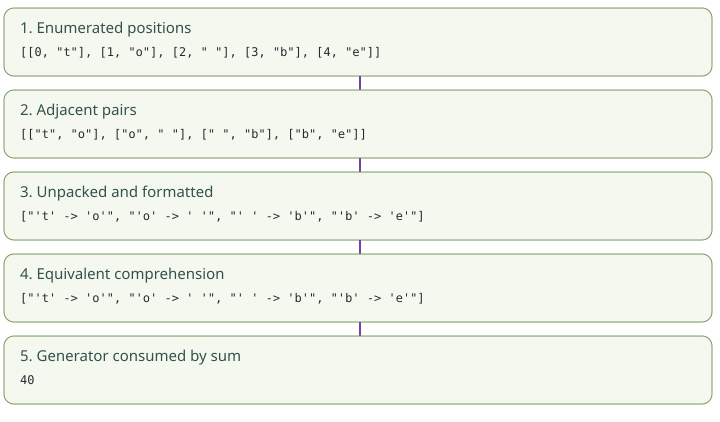

In [26]:
draw_trace()

### P0.5.3 · Read and run the code

Enumerate and zip return iterators. Convert them to lists here so the complete small result can be inspected more than once.

In the loop header, two names receive the two items of each pair. Mismatched unpacking lengths raise an error rather than silently dropping values.

Read a comprehension in execution order: for each pair, unpack it, calculate the label, then collect the label.

A generator uses parentheses and produces items lazily. Sum consumes each supplied number and accumulates a total.

Range excludes its stopping boundary. Break leaves the current loop; neither operation changes how the next-target offset is defined.

### Change one thing

**Shorten the text to two characters**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [27]:
FRAMES.clear()
change = 1
text = "to be" if not change else "to"
show("Enumerated positions", list(enumerate(text)))
pairs = list(zip(text, text[1:]))
show("Adjacent pairs", pairs)
labels = []
for left, right in pairs:
    labels.append(f"{left!r} -> {right!r}")
show("Unpacked and formatted", labels)
show("Equivalent comprehension", [f"{a!r} -> {b!r}" for a, b in pairs])
lengths = (len(item) for item in labels)
show("Generator consumed by sum", sum(lengths))

Enumerated positions: [[0, "t"], [1, "o"]]
Adjacent pairs: [["t", "o"]]
Unpacked and formatted: ["'t' -> 'o'"]
Equivalent comprehension: ["'t' -> 'o'"]
Generator consumed by sum: 10


### A useful distinction

zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.

In [28]:
g = (i * i for i in range(3))
assert list(g) == [0, 1, 4]
assert list(g) == []
try:
    list(zip([1, 2], [3], strict=True))
except ValueError:
    print("strict zip detects unequal lengths.")

strict zip detects unequal lengths.


### ✋ Your turn

For "abcd", use zip and a shifted slice to put the adjacent pairs in answer.

In [29]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [("a", "b"), ("b", "c"), ("c", "d")], 'zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [30]:
#@title Show a solution { display-mode: "form" }
answer = list(zip("abcd", "abcd"[1:]))

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [("a", "b"), ("b", "c"), ("c", "d")], 'zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.'
    print("✓ right:", answer)

✓ right: [('a', 'b'), ('b', 'c'), ('c', 'd')]


### P0.5.4 · Find it in the model

The tokenizer encodes text with a comprehension. The training sampler builds a list of windows, then stacks those windows into a batch.

Parameter counting uses a generator: ask each parameter for its number of elements, then sum those counts. No intermediate list is required.

The model constructs repeated blocks with a comprehension and passes them into a container. Each constructor call creates a distinct block unless sharing is explicitly requested.

An attention expression can apply the same reshape to query, key and value tensors. Unpacking names the three returned results.

Next, give these transformations clear function boundaries so inputs and outputs remain understandable.

```python
sum(p.numel() for p in model.parameters())
[Block(cfg) for _ in range(cfg.n_layer)]
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** How many adjacent pairs come from four characters?

<details><summary>Check your explanation</summary>

3. zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.

</details>

## P0.6 · Functions with clear contracts

A function contract states valid inputs, returned values, and side effects. Type hints describe intent; checks enforce it.

**Prerequisites:** Follow iteration and unpacking

**Predict:** Can three source positions supply three next-character targets?

**Mental model:** A reusable function needs a clear agreement with its caller. State what values it accepts, what it returns, and whether it changes any inputs.

<a data-compat-cell="p0-functions-and-f-strings"></a>

### P0.6.1 · Understand the need

A reusable function needs a clear agreement with its caller. State what values it accepts, what it returns, and whether it changes any inputs.

A training window requires one more source position than its context length. Otherwise the final input has no next-character target.

Defaults make a common choice convenient, while keyword arguments make a call easier to read. Neither replaces checking the actual input.

Returning two values packages them into a tuple. The caller can unpack that tuple into two descriptive names.

A type hint documents an expected kind of value. Python does not automatically enforce ordinary type hints during a function call.

### P0.6.2 · Follow the values

The source IDs are zero through five. The default context size is three, and the experiment chooses a starting position.

With start zero, the input contains zero, one and two. The function constructs this slice without mutating the source list.

The targets contain one, two and three. Each target names the position immediately after its corresponding input.

Inspect the original list after the call. It still contains all six IDs because slicing created new outer lists.

The two returned windows have equal length and the expected overlap. Move the start once and check that both windows move together.

In [31]:
FRAMES.clear()
change = 0
def window(ids: list[int], start: int, size: int = 3):
    if start < 0 or size < 1 or start + size >= len(ids):
        raise ValueError("Need a complete window plus its next target")
    return ids[start:start+size], ids[start+1:start+size+1]
ids = [0, 1, 2, 3, 4, 5]
show("Arguments", {"ids": ids, "start": change, "size": 3})
x, y = window(ids, start=change)
show("Returned inputs", x)
show("Returned targets", y)
show("Input list is unchanged", ids)
show("Contract", {"equal lengths": len(x) == len(y), "next-token shift": x[1:] == y[:-1]})

Arguments: {"ids": [0, 1, 2, 3, 4, 5], "start": 0, "size": 3}
Returned inputs: [0, 1, 2]
Returned targets: [1, 2, 3]
Input list is unchanged: [0, 1, 2, 3, 4, 5]
Contract: {"equal lengths": true, "next-token shift": true}


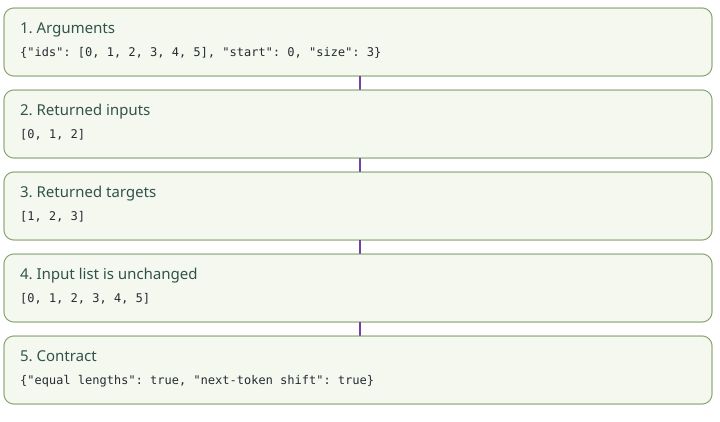

In [32]:
draw_trace()

### P0.6.3 · Read and run the code

Read the function signature as its input contract. The size argument has a default; the start argument is supplied by name in the call.

The conditional rejects negative starts, empty windows and a final input without a target. Raising ValueError explains the violated requirement.

Return creates the two slices. A caller that does not return a value explicitly instead hands back None.

Assign the returned inputs to x and the returned targets to y. Local variables inside the function do not automatically become names in the caller's scope.

Avoid mutable default containers for accumulated results. Use None as a sentinel and construct a new list within each call when independent state is intended.

### Change one thing

**Move start from 0 to 1**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [33]:
FRAMES.clear()
change = 1
def window(ids: list[int], start: int, size: int = 3):
    if start < 0 or size < 1 or start + size >= len(ids):
        raise ValueError("Need a complete window plus its next target")
    return ids[start:start+size], ids[start+1:start+size+1]
ids = [0, 1, 2, 3, 4, 5]
show("Arguments", {"ids": ids, "start": change, "size": 3})
x, y = window(ids, start=change)
show("Returned inputs", x)
show("Returned targets", y)
show("Input list is unchanged", ids)
show("Contract", {"equal lengths": len(x) == len(y), "next-token shift": x[1:] == y[:-1]})

Arguments: {"ids": [0, 1, 2, 3, 4, 5], "start": 1, "size": 3}
Returned inputs: [1, 2, 3]
Returned targets: [2, 3, 4]
Input list is unchanged: [0, 1, 2, 3, 4, 5]
Contract: {"equal lengths": true, "next-token shift": true}


### A useful distinction

Type hints do not validate values at runtime, and a mutable default object is shared between calls.

In [34]:
for args in [([0,1],0,2), ([0,1,2],-1,1), ([0,1,2],0,0)]:
    try:
        window(*args)
    except ValueError as error:
        print(error)
    else:
        raise AssertionError("Invalid window was accepted")

Need a complete window plus its next target
Need a complete window plus its next target
Need a complete window plus its next target


### ✋ Your turn

Use window on IDs [0,1,2,3,4] with start=1 and size=2; put the returned tuple in answer.

In [35]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2], [2, 3]), 'Type hints do not validate values at runtime, and a mutable default object is shared between calls.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [36]:
#@title Show a solution { display-mode: "form" }
answer = window([0, 1, 2, 3, 4], start=1, size=2)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2], [2, 3]), 'Type hints do not validate values at runtime, and a mutable default object is shared between calls.'
    print("✓ right:", answer)

✓ right: ([1, 2], [2, 3])


### P0.6.4 · Find it in the model

The model's forward method accepts token IDs and optionally targets. Without targets it can return predictions and no loss.

Training passes both inputs and targets; generation passes only inputs. A clear return contract keeps both call sites readable.

Batch functions should make boundary behavior explicit. A silently shortened slice is legal Python but may violate the model's expected batch shape.

Assertions are useful during experiments; explicit exceptions provide input validation that remains active when Python assertions are disabled.

Next, apply the same contracts at the file and configuration boundaries of a program.

```python
def forward(self, idx, targets=None):
    ...
    return logits, loss
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Can three source positions supply three next-character targets?

<details><summary>Check your explanation</summary>

No; a fourth source position is needed. Type hints do not validate values at runtime, and a mutable default object is shared between calls.

</details>

## P0.7 · Imports, files, and configuration

Read text with an explicit encoding and keep configuration with the data and model that use it.

**Prerequisites:** Functions with clear contracts

**Predict:** What does json.loads receive?

**Mental model:** A training program needs a stable way to find its text and interpret its bytes. A path and an explicit encoding make that boundary visible.

### P0.7.1 · Understand the need

A training program needs a stable way to find its text and interpret its bytes. A path and an explicit encoding make that boundary visible.

A relative path is interpreted from the current working directory. Moving a notebook can therefore change which file an identical-looking expression opens.

Configuration records choices such as context length and vocabulary. Those choices affect the meaning and shape of the data.

JSON stores ordinary strings, numbers, lists and mappings in a portable text format. It does not automatically serialize an arbitrary model object.

Keep loading separate from computation. A small known input makes a file problem easier to distinguish from a model problem.

### P0.7.2 · Follow the values

The example creates a temporary sample file. Its temporary parent directory is infrastructure; its stable name is sample dot text.

Reading with U T F eight returns a Python string, including the final newline. Switch the experiment to the accented word to inspect another valid input.

Build a configuration containing the context length and this sample's sorted vocabulary. Both describe the data the program will use.

Serialize the mapping as JSON text. Characters are preserved explicitly, while the newline has an escaped representation inside the JSON string.

Parse that text back into Python and compare the result. The round trip checks that this configuration survived serialization.

In [37]:
FRAMES.clear()
change = 0
from pathlib import Path
import json
import tempfile
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "sample.txt"
    path.write_text("to be\n" if not change else "café\n", encoding="utf-8")
    show("File name", path.name)
    text = path.read_text(encoding="utf-8")
    show("Loaded text", repr(text))
    config = {"context": 3, "vocabulary": sorted(set(text))}
    show("Configuration", config)
    serialized = json.dumps(config, ensure_ascii=False)
    show("JSON text", serialized)
    restored = json.loads(serialized)
    show("Round-trip equality", restored == config)

File name: "sample.txt"
Loaded text: "'to be\\n'"
Configuration: {"context": 3, "vocabulary": ["\n", " ", "b", "e", "o", "t"]}
JSON text: "{\"context\": 3, \"vocabulary\": [\"\\n\", \" \", \"b\", \"e\", \"o\", \"t\"]}"
Round-trip equality: true


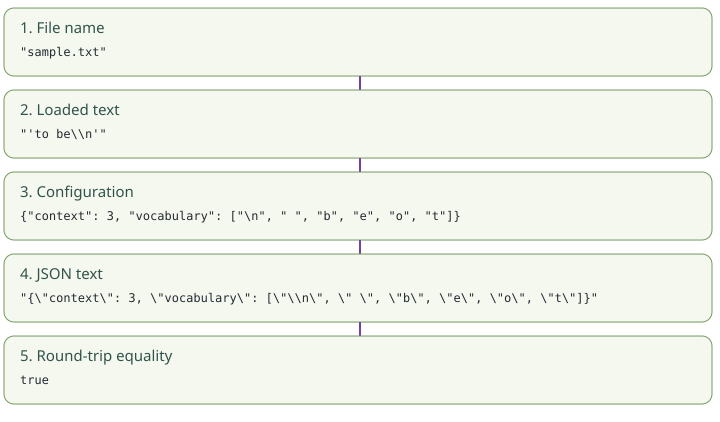

In [38]:
draw_trace()

### P0.7.3 · Read and run the code

From pathlib import Path brings one class into the current namespace. Importing json instead brings the module name, so its functions are reached through that name.

The with statement manages a resource lifetime. This example cleans up its temporary folder after the block, even when an exception occurs.

Read text with an explicit encoding. For a real dataset, validate the expected file rather than silently substituting unrelated text when loading fails.

Dumps converts a supported Python value into JSON text; loads parses JSON text back into a Python value. Their file-based relatives operate on open files.

A script's main guard separates work done when executed directly from definitions made available when imported. That keeps imports from unexpectedly starting training.

### Change one thing

**Read a UTF-8 accented word**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [39]:
FRAMES.clear()
change = 1
from pathlib import Path
import json
import tempfile
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "sample.txt"
    path.write_text("to be\n" if not change else "café\n", encoding="utf-8")
    show("File name", path.name)
    text = path.read_text(encoding="utf-8")
    show("Loaded text", repr(text))
    config = {"context": 3, "vocabulary": sorted(set(text))}
    show("Configuration", config)
    serialized = json.dumps(config, ensure_ascii=False)
    show("JSON text", serialized)
    restored = json.loads(serialized)
    show("Round-trip equality", restored == config)

File name: "sample.txt"
Loaded text: "'café\\n'"
Configuration: {"context": 3, "vocabulary": ["\n", "a", "c", "f", "é"]}
JSON text: "{\"context\": 3, \"vocabulary\": [\"\\n\", \"a\", \"c\", \"f\", \"é\"]}"
Round-trip equality: true


### A useful distinction

A relative path depends on the working directory. JSON configuration does not contain model weights.

### ✋ Your turn

Serialize and restore {"context": 4, "heads": 2}, then put the restored dictionary in answer.

In [40]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == {"context": 4, "heads": 2}, 'A relative path depends on the working directory. JSON configuration does not contain model weights.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [41]:
#@title Show a solution { display-mode: "form" }
import json
answer = json.loads(json.dumps({"context": 4, "heads": 2}))

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == {"context": 4, "heads": 2}, 'A relative path depends on the working directory. JSON configuration does not contain model weights.'
    print("✓ right:", answer)

✓ right: {'context': 4, 'heads': 2}


### P0.7.4 · Find it in the model

The training recipe reads a dataset from a path and records configuration alongside its outputs. Those records allow a later notebook to interpret the run.

Import torch as a module and its functional namespace under an alias; these aliases are ordinary Python names, not special model syntax.

Weight files and configuration files serve different purposes. Tensor serialization will arrive in PyTorch, while JSON remains useful for human-readable settings.

The vocabulary's ordering must be preserved, not merely its number of entries. Otherwise loaded weights can be attached to different characters.

Next, group a vocabulary and the functions that use it into one object.

```python
text = Path(args.text).read_text(encoding="utf-8")
config_json = json.dumps(config, indent=2)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What does json.loads receive?

<details><summary>Check your explanation</summary>

JSON text. A relative path depends on the working directory. JSON configuration does not contain model weights.

</details>

# Section 3 · Read model code

- P0.8 · Classes and instances
- P0.9 · Read real model Python
- P0.10 · Text-to-batch capstone

## P0.8 · Classes and instances

An instance keeps its own state. Its methods use self to access that state.

**Prerequisites:** Imports, files, and configuration

**Predict:** Two tokenizer instances can give one ID different meanings.

**Mental model:** A tokenizer needs both a vocabulary and operations that use it. A class describes how to build an object that keeps those pieces together.

### P0.8.1 · Understand the need

A tokenizer needs both a vocabulary and operations that use it. A class describes how to build an object that keeps those pieces together.

Constructing a tokenizer creates an instance. Constructing another tokenizer creates another instance with its own vocabulary.

The method parameter self refers to the instance receiving the call. It tells the method which stored mapping to consult.

The same integer IDs can decode differently in two tokenizer instances. The object state supplies the meaning that the bare IDs do not contain.

This is the same programming pattern used to organize neural network layers. First understand it with a small vocabulary you can inspect completely.

### P0.8.2 · Follow the values

Construct the first tokenizer from the letters a and b. Its sorted vocabulary gives the letter a ID zero and the letter b ID one.

Construct the second from x and y. It has its own vocabulary and its own mapping, with the same number of entries.

Ask the first object to encode b followed by a. It returns one followed by zero using the first mapping.

Ask the second object to decode those same IDs. It returns y followed by x, because the second vocabulary has different characters.

The two stored dictionaries are separate objects. Add c to the first construction in the experiment and inspect which object's state changes.

In [42]:
FRAMES.clear()
change = 0
class Tokenizer:
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
    def encode(self, text):
        return [self.stoi[ch] for ch in text]
    def decode(self, ids):
        return "".join(self.chars[i] for i in ids)
first = Tokenizer("ab" if not change else "abc")
second = Tokenizer("xy")
show("First object's vocabulary", first.chars)
show("Second object's vocabulary", second.chars)
show("First object encodes ba", first.encode("ba"))
show("Second object decodes the same IDs", second.decode([1, 0]))
show("Separate instance state", first.stoi is not second.stoi)

First object's vocabulary: ["a", "b"]
Second object's vocabulary: ["x", "y"]
First object encodes ba: [1, 0]
Second object decodes the same IDs: "yx"
Separate instance state: true


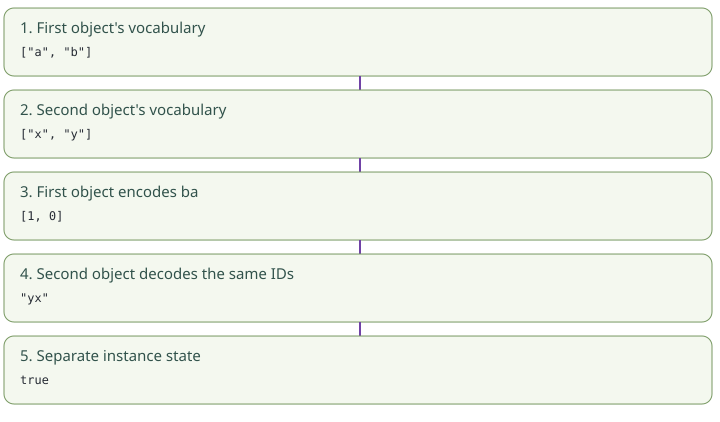

In [43]:
draw_trace()

### P0.8.3 · Read and run the code

The class statement defines the construction and behavior of Tokenizer. Calling the class creates an instance and invokes its initialization method.

Inside initialization, two attributes store the character list and the character-to-ID mapping. Both belong to this instance, reached through self.

The encode method receives the instance through self and the requested text through its explicit argument. Calling first dot encode supplies the instance automatically.

Decode reads the stored character list and joins its selected entries. The two methods share state through self rather than through unrelated global variables.

Keep per-instance mutable data inside initialization. A mutable class attribute would instead be shared across instances unless deliberately overridden.

### Change one thing

**Add c to the first vocabulary**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [44]:
FRAMES.clear()
change = 1
class Tokenizer:
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
    def encode(self, text):
        return [self.stoi[ch] for ch in text]
    def decode(self, ids):
        return "".join(self.chars[i] for i in ids)
first = Tokenizer("ab" if not change else "abc")
second = Tokenizer("xy")
show("First object's vocabulary", first.chars)
show("Second object's vocabulary", second.chars)
show("First object encodes ba", first.encode("ba"))
show("Second object decodes the same IDs", second.decode([1, 0]))
show("Separate instance state", first.stoi is not second.stoi)

First object's vocabulary: ["a", "b", "c"]
Second object's vocabulary: ["x", "y"]
First object encodes ba: [1, 0]
Second object decodes the same IDs: "yx"
Separate instance state: true


### A useful distinction

self is the receiving instance, not one global object shared by all instances.

### ✋ Your turn

Create a Tokenizer for "cab", encode "bac", and put the resulting list in answer.

In [45]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 0, 2], 'self is the receiving instance, not one global object shared by all instances.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [46]:
#@title Show a solution { display-mode: "form" }
answer = Tokenizer("cab").encode("bac")

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [1, 0, 2], 'self is the receiving instance, not one global object shared by all instances.'
    print("✓ right:", answer)

✓ right: [1, 0, 2]


### P0.8.4 · Find it in the model

The current tokenizer uses this exact object pattern. A saved model must be paired with the tokenizer state that was used to interpret its training data.

A neural network module also keeps state, including submodules and learned tensors. Its forward method uses that state to calculate an output.

A method call and an attribute lookup are different: parentheses execute a callable, while an attribute expression retrieves the stored value or method.

Composition means storing another object as an attribute. A transformer stores attention and feed-forward modules this way.

Next, extend this foundation to inheritance, configuration objects and the compact syntax in the actual model file.

```python
tokenizer = Tokenizer(text)
ids = tokenizer.encode(prompt)
reply = tokenizer.decode(generated_ids)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Two tokenizer instances can give one ID different meanings.

<details><summary>Check your explanation</summary>

True; their vocabularies can differ. self is the receiving instance, not one global object shared by all instances.

</details>

## P0.9 · Read real model Python

Inheritance extends behavior; composition stores collaborating objects; decorators modify definitions.

**Prerequisites:** Classes and instances

**Predict:** Which object supplies PyTorch’s call-to-forward behavior?

**Mental model:** A model file can look unfamiliar even when its calculations are small. Separate Python's object machinery from the numerical operations the library provides.

### P0.9.1 · Understand the need

A model file can look unfamiliar even when its calculations are small. Separate Python's object machinery from the numerical operations the library provides.

A configuration object names settings such as width and head count. A data class generates routine initialization from declared fields.

Inheritance gives a class access to behavior defined by a parent. Super lets a method cooperate with that inherited behavior.

An instance can be callable when its class provides a call method. In PyTorch, the module's call machinery dispatches to your forward method and manages hooks.

You only need to read the decorators used by this course. Writing a general decorator framework is a separate programming topic.

### P0.9.2 · Follow the values

Create a configuration with width four and two heads. Converting it to a dictionary makes the named settings visible.

The child operation initializes its inherited amount from the configuration width. This is object state, not a tensor axis being calculated.

Calling the child on three first adds four and then doubles the result, giving fourteen. Changing width to eight changes this result to twenty-two.

A star unpacks the tuple two and three into positional arguments. Power receives two arguments and returns eight.

The configuration still holds its original named settings after these calculations. Computed data and configuration are different objects with different purposes.

In [47]:
FRAMES.clear()
change = 0
from dataclasses import dataclass, asdict
@dataclass(frozen=True)
class Config:
    width: int = 4
    heads: int = 2
class Add:
    def __init__(self, amount):
        self.amount = amount
    def __call__(self, value):
        return value + self.amount
class TwiceAdd(Add):
    def __init__(self, amount):
        super().__init__(amount)
    def __call__(self, value):
        return super().__call__(value) * 2
cfg = Config(width=8 if change else 4)
show("Configuration fields", asdict(cfg))
operation = TwiceAdd(cfg.width)
show("Inherited instance attribute", operation.amount)
show("Call an instance", operation(3))
values = (2, 3)
show("Unpack positional arguments", pow(*values))
show("Configuration stays separate from data", asdict(cfg))

Configuration fields: {"width": 4, "heads": 2}
Inherited instance attribute: 4
Call an instance: 14
Unpack positional arguments: 8
Configuration stays separate from data: {"width": 4, "heads": 2}


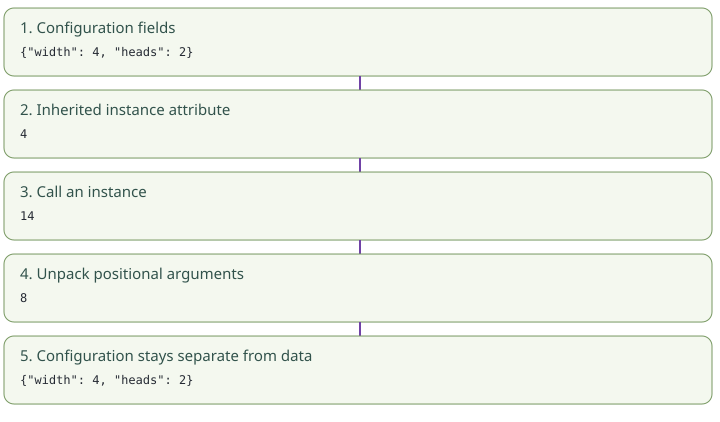

In [48]:
draw_trace()

### P0.9.3 · Read and run the code

The decorator above Config asks dataclass to generate routine class methods. Frozen prevents ordinary reassignment of its declared fields.

The child class names its parent in parentheses. Its initializer uses super to run the parent initialization rather than duplicating it.

The call method makes the instance usable with parentheses. Its behavior is defined here explicitly; a plain class does not acquire a forward convention by itself.

A single star expands positional arguments, while a double star expands keyword mappings. Type annotations describe the intended values without enforcing every constraint at runtime.

Static methods omit an automatic instance argument. Context managers and decorators such as no grad will later control a region of PyTorch execution.

### Change one thing

**Increase configuration width to 8**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [49]:
FRAMES.clear()
change = 1
from dataclasses import dataclass, asdict
@dataclass(frozen=True)
class Config:
    width: int = 4
    heads: int = 2
class Add:
    def __init__(self, amount):
        self.amount = amount
    def __call__(self, value):
        return value + self.amount
class TwiceAdd(Add):
    def __init__(self, amount):
        super().__init__(amount)
    def __call__(self, value):
        return super().__call__(value) * 2
cfg = Config(width=8 if change else 4)
show("Configuration fields", asdict(cfg))
operation = TwiceAdd(cfg.width)
show("Inherited instance attribute", operation.amount)
show("Call an instance", operation(3))
values = (2, 3)
show("Unpack positional arguments", pow(*values))
show("Configuration stays separate from data", asdict(cfg))

Configuration fields: {"width": 8, "heads": 2}
Inherited instance attribute: 8
Call an instance: 22
Unpack positional arguments: 8
Configuration stays separate from data: {"width": 8, "heads": 2}


### A useful distinction

A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.

### ✋ Your turn

Construct Config(width=8, heads=2) and put its width divided by its head count, using integer division, in answer.

In [50]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [51]:
#@title Show a solution { display-mode: "form" }
cfg = Config(width=8, heads=2)
answer = cfg.width // cfg.heads

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.'
    print("✓ right:", answer)

✓ right: 4


### P0.9.4 · Find it in the model

The transformer configuration is a data class. The model and block classes inherit from the neural network module base class and initialize it with super.

The model constructs several blocks from the configuration and stores them in a registered container. Star expansion passes the constructed blocks into that container.

The library's model call eventually invokes forward. Calling the model object is the normal entry point because the library has behavior around forward too.

A no-grad decorator changes how operations inside generation are recorded for differentiation. It does not mean the generation function stops performing calculations.

Next, assemble the Python data pipeline and practice reading its contracts from beginning to end.

```python
@dataclass(frozen=True)
class Config:
    d_model: int = 28

class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which object supplies PyTorch’s call-to-forward behavior?

<details><summary>Check your explanation</summary>

nn.Module. A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.

</details>

## P0.10 · Text-to-batch capstone

Split the stream before making windows, preserve the vocabulary, and verify the next-character shift.

**Prerequisites:** Read real model Python

**Predict:** When should the stream be split for this windowing example?

**Mental model:** The Python foundations now form a working preparation pipeline. Its final product is a set of input sequences paired with the characters that follow them.

<a id="python-read-change"></a>

<a data-compat-cell="p0-read-a-short-program-then-change-it"></a>

<a data-compat-cell="p0-practice"></a>

### P0.10.1 · Understand the need

The Python foundations now form a working preparation pipeline. Its final product is a set of input sequences paired with the characters that follow them.

Keep the vocabulary fixed while dividing the stream into training and validation portions. Here the vocabulary is an explicit character inventory for a small illustration.

Split the stream before constructing windows. Otherwise overlapping windows can accidentally share source positions across a split boundary.

Each window of three inputs needs four source positions to obtain its three shifted targets. Boundary checks are part of the data contract.

This small capstone checks preparation, not language-model quality. The training unit will explain evaluation and the actual dataset recipe.

### P0.10.2 · Follow the values

Build the vocabulary once and encode the full example text with it. The resulting integers retain the original order of positions.

Split the encoded stream after position eleven. Training and validation hold separate portions, and neither window builder crosses this boundary.

Choose two valid starts from the training portion. Each input window contains three positions, so the collection has two sequences of length three.

Shift each start and stop one place forward for the targets. The targets stay aligned with their corresponding input sequences.

Decode the first pair to check the meaning of the integers. Move both starts in the lab and confirm that every target remains the following character.

In [52]:
FRAMES.clear()
change = 0
text = "to be or not to be\n"
chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
ids = [stoi[ch] for ch in text]
show("Vocabulary", chars)
cut = 12
train, valid = ids[:cut], ids[cut:]
show("Partition before windowing", {"train": train, "valid": valid})
size = 3
starts = [0, 1] if not change else [2, 3]
x = [train[i:i+size] for i in starts]
show("Input windows", x)
y = [train[i+1:i+size+1] for i in starts]
show("Target windows", y)
show("Decoded example", {"input": "".join(chars[i] for i in x[0]), "target": "".join(chars[i] for i in y[0])})
assert all(len(a) == len(b) == size and a[1:] == b[:-1] for a, b in zip(x, y))

Vocabulary: ["\n", " ", "b", "e", "n", "o", "r", "t"]
Partition before windowing: {"train": [7, 5, 1, 2, 3, 1, 5, 6, 1, 4, 5, 7], "valid": [1, 7, 5, 1, 2, 3, 0]}
Input windows: [[7, 5, 1], [5, 1, 2]]
Target windows: [[5, 1, 2], [1, 2, 3]]
Decoded example: {"input": "to ", "target": "o b"}


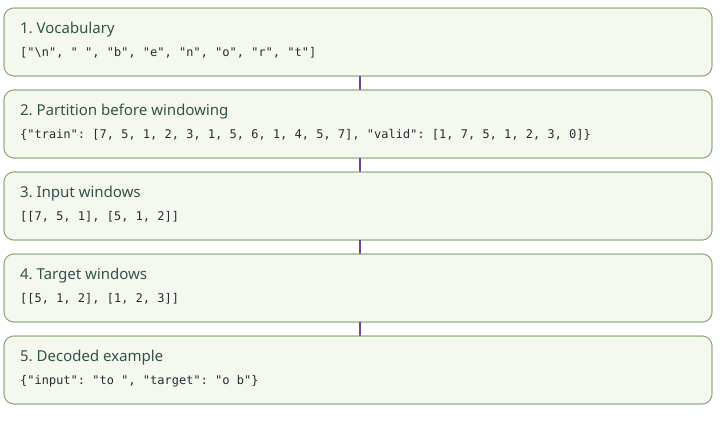

In [53]:
draw_trace()

### P0.10.3 · Read and run the code

Construct the vocabulary mapping before encoding. Keeping one mapping avoids giving the same ID different meanings in different splits.

A list comprehension creates one slice per chosen start. The starts are explicit here so you can inspect every source position.

A second comprehension applies the one-position target offset. Do not independently shuffle this target collection.

The assertion checks lengths and overlapping positions. A stronger boundary test also compares each pair against the original stream and its chosen start.

Test the last valid start and reject the first invalid one. Empty data and unknown characters should produce deliberate feedback instead of misleading batches.

### Change one thing

**Move both sampled starts forward**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [54]:
FRAMES.clear()
change = 1
text = "to be or not to be\n"
chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
ids = [stoi[ch] for ch in text]
show("Vocabulary", chars)
cut = 12
train, valid = ids[:cut], ids[cut:]
show("Partition before windowing", {"train": train, "valid": valid})
size = 3
starts = [0, 1] if not change else [2, 3]
x = [train[i:i+size] for i in starts]
show("Input windows", x)
y = [train[i+1:i+size+1] for i in starts]
show("Target windows", y)
show("Decoded example", {"input": "".join(chars[i] for i in x[0]), "target": "".join(chars[i] for i in y[0])})
assert all(len(a) == len(b) == size and a[1:] == b[:-1] for a, b in zip(x, y))

Vocabulary: ["\n", " ", "b", "e", "n", "o", "r", "t"]
Partition before windowing: {"train": [7, 5, 1, 2, 3, 1, 5, 6, 1, 4, 5, 7], "valid": [1, 7, 5, 1, 2, 3, 0]}
Input windows: [[1, 2, 3], [2, 3, 1]]
Target windows: [[2, 3, 1], [3, 1, 5]]
Decoded example: {"input": " be", "target": "be "}


### A useful distinction

Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.

### ✋ Your turn

For IDs [0,1,2,3,4], create the final valid length-3 input/target pair and put it in answer.

In [55]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2, 3], [2, 3, 4]), 'Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [56]:
#@title Show a solution { display-mode: "form" }
ids = [0, 1, 2, 3, 4]
start = len(ids) - 3 - 1
answer = (ids[start:start+3], ids[start+1:start+4])

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2, 3], [2, 3, 4]), 'Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.'
    print("✓ right:", answer)

✓ right: ([1, 2, 3], [2, 3, 4])


### P0.10.4 · Find it in the model

The training sampler performs the same slicing operation on a tensor of IDs. Stacking adds a batch axis without changing the next-character objective.

The current character model uses its full dataset vocabulary. Phyll adds tokenizer-specific special tokens and padding rules that are taught in its data lesson.

A character vocabulary inventory differs from fitting statistical preprocessing. In other tasks, learned preprocessing must be fitted on the training data according to the evaluation design.

You can now read the Python surrounding the tensor operations: imports, state, functions, comprehensions and the model's classes.

Continue to PyTorch. The next task is to preserve these meanings while operating on complete tensors of values.

```python
starts = torch.randint(len(data) - context, (batch_size,))
x = torch.stack([data[i:i+context] for i in starts])
y = torch.stack([data[i+1:i+context+1] for i in starts])
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** When should the stream be split for this windowing example?

<details><summary>Check your explanation</summary>

Before creating windows. Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.

</details>